In [ ]:
# Data Preprocessing and Visualisation

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df=pd.read_csv('Raw_accidents_data.csv')
df.head()

,Accident_ID,Speed,Traffic_Volume,Driver_Alcohol,Weather,Time_of_Day,Road_Type,Accident_Risk,Passenger_Count,Date,Road_Condition,Vehicle_Type,Driver_Experience_yrs,Severity
0,ACC01011,79.760911,50.452617,0.0,Fog,Morning,Rural,73.772120,1.0,01-01-2023 00:10,Slippery,Car,37,Fatal
1,ACC01888,66.360916,82.190413,0.0,Fog,Night,Highway,83.482605,1.0,01-01-2023 00:29,Slippery,Auto,17,Fatal
2,ACC00801,74.074257,22.229149,0.0,Clear,Afternoon,Highway,43.615109,0.0,01-01-2023 20:07,Dry,Bus,23,Minor
3,ACC00753,45.361901,75.056853,1.0,Rain,Morning,Rural,84.816125,4.0,02-01-2023 00:41,Slippery,Bus,27,Fatal
4,ACC01860,63.904828,47.169485,1.0,Clear,Night,Highway,92.203479,4.0,02-01-2023 00:46,Dry,CAR,16,Fatal


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accident_ID            3000 non-null   object 
 1   Speed                  2940 non-null   float64
 2   Traffic_Volume         2940 non-null   float64
 3   Driver_Alcohol         2940 non-null   float64
 4   Weather                2940 non-null   object 
 5   Time_of_Day            2940 non-null   object 
 6   Road_Type              2940 non-null   object 
 7   Accident_Risk          2940 non-null   float64
 8   Passenger_Count        2048 non-null   float64
 9   Date                   3000 non-null   object 
 10  Road_Condition         2475 non-null   object 
 11  Vehicle_Type           3000 non-null   object 
 12  Driver_Experience_yrs  3000 non-null   int64  
 13  Severity               2940 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 328.2+ 

In [75]:
df.describe()

,Speed,Traffic_Volume,Driver_Alcohol,Accident_Risk,Passenger_Count,Driver_Experience_yrs
count,2940.000000,2940.000000,2940.000000,2940.000000,2048.000000,3000.000000
mean,60.522487,49.357892,0.189456,53.014015,2.481445,19.462000
std,14.755532,19.905295,0.391937,15.941945,1.721625,11.633214
min,20.000000,5.000000,0.000000,0.286028,0.000000,0.000000
25%,50.610941,35.756288,0.000000,42.040132,1.000000,9.000000
50%,60.374239,49.593407,0.000000,52.673159,2.000000,19.000000
75%,70.191441,62.747899,0.000000,63.807256,4.000000,30.000000
max,117.790972,114.861859,1.000000,110.309844,5.000000,39.000000


In [76]:
df.isna().sum()

Accident_ID                0
Speed                     60
Traffic_Volume            60
Driver_Alcohol            60
Weather                   60
Time_of_Day               60
Road_Type                 60
Accident_Risk             60
Passenger_Count          952
Date                       0
Road_Condition           525
Vehicle_Type               0
Driver_Experience_yrs      0
Severity                  60
dtype: int64

In [77]:
cat_cols = ['Driver_Alcohol','Weather','Time_of_Day','Road_Type','Passenger_Count','Road_Condition','Vehicle_Type','Driver_Experience_yrs','Severity']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [78]:
df[['Speed','Traffic_Volume','Accident_Risk']]=df[['Speed','Traffic_Volume','Accident_Risk']].fillna(df[['Speed','Traffic_Volume','Accident_Risk']].mean())

In [79]:
df.isna().sum()

Accident_ID              0
Speed                    0
Traffic_Volume           0
Driver_Alcohol           0
Weather                  0
Time_of_Day              0
Road_Type                0
Accident_Risk            0
Passenger_Count          0
Date                     0
Road_Condition           0
Vehicle_Type             0
Driver_Experience_yrs    0
Severity                 0
dtype: int64

In [80]:
df.duplicated().sum()

0

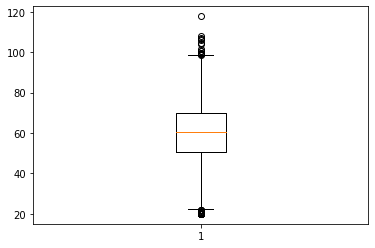

In [81]:
plt.boxplot(df["Speed"])
plt.show()


#speed 100-120 is not consider as outlier.

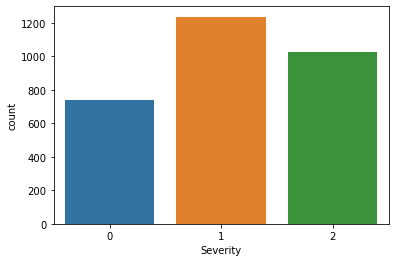

In [93]:
sns.countplot(x='Severity', data=df)
plt.show()

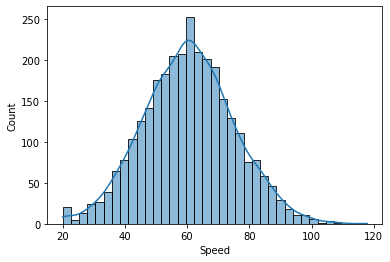

In [94]:
sns.histplot(df['Speed'], kde=True)
plt.show()

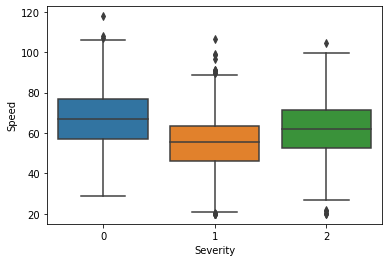

In [95]:
sns.boxplot(x='Severity', y='Speed', data=df)
plt.show()

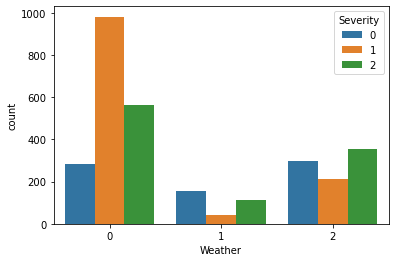

In [96]:

sns.countplot(x='Weather', hue='Severity', data=df)
plt.show()

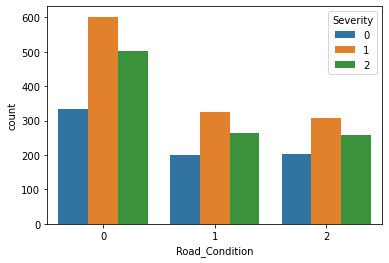

In [97]:

sns.countplot(x='Road_Condition', hue='Severity', data=df)
plt.show()

In [98]:
df.to_csv("improved_accident_data.csv", index=False)

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


cat_cols = ['Weather','Time_of_Day','Road_Type','Road_Condition','Vehicle_Type','Severity']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Accident_ID,Speed,Traffic_Volume,Driver_Alcohol,Weather,Time_of_Day,Road_Type,Accident_Risk,Passenger_Count,Date,Road_Condition,Vehicle_Type,Driver_Experience_yrs,Severity
0,ACC01011,79.760911,50.452617,0.0,1,1,2,73.772120,1.0,01-01-2023 00:10,1,3,37,0
1,ACC01888,66.360916,82.190413,0.0,1,2,1,83.482605,1.0,01-01-2023 00:29,1,0,17,0
2,ACC00801,74.074257,22.229149,0.0,0,0,1,43.615109,0.0,01-01-2023 20:07,0,1,23,1
3,ACC00753,45.361901,75.056853,1.0,2,1,2,84.816125,4.0,02-01-2023 00:41,1,1,27,0
4,ACC01860,63.904828,47.169485,1.0,0,2,1,92.203479,4.0,02-01-2023 00:46,0,2,16,0


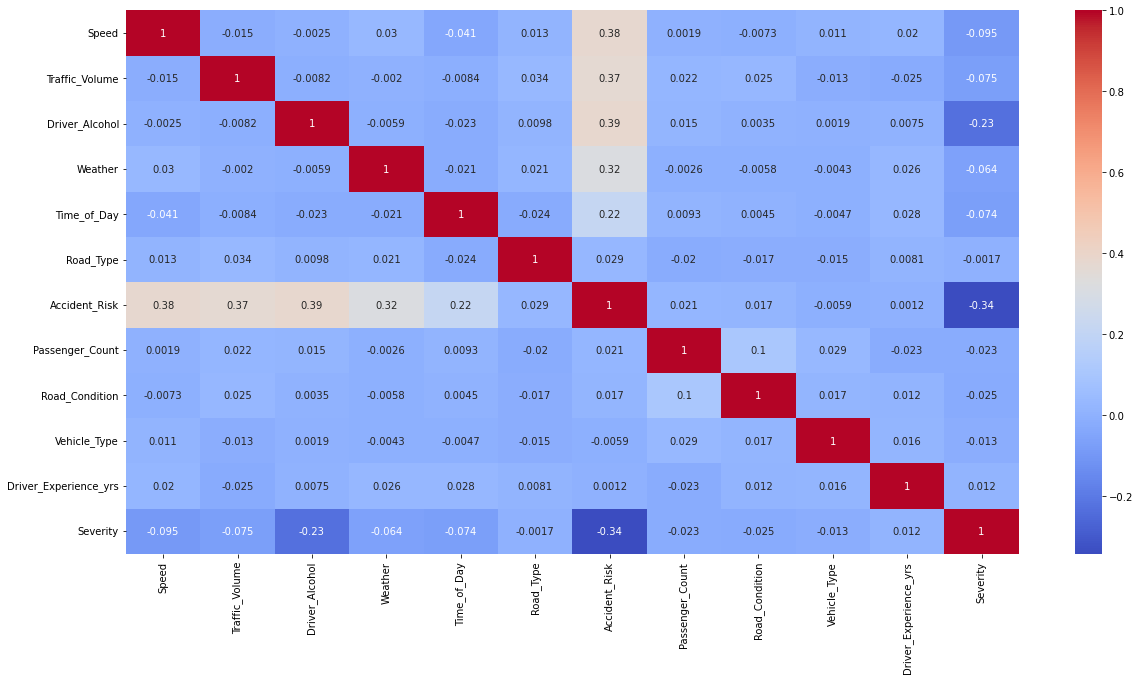

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation
corr = numeric_df.corr()

plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [84]:
#removing irrelevent Features 
df.drop(['Date','Accident_ID','Passenger_Count','Vehicle_Type','Driver_Experience_yrs'],axis=1,inplace=True)

In [85]:
df.head()

,Speed,Traffic_Volume,Driver_Alcohol,Weather,Time_of_Day,Road_Type,Accident_Risk,Road_Condition,Severity
0,79.760911,50.452617,0.0,1,1,2,73.772120,1,0
1,66.360916,82.190413,0.0,1,2,1,83.482605,1,0
2,74.074257,22.229149,0.0,0,0,1,43.615109,0,1
3,45.361901,75.056853,1.0,2,1,2,84.816125,1,0
4,63.904828,47.169485,1.0,0,2,1,92.203479,0,0


In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
num_cols=['Speed','Traffic_Volume','Accident_Risk']